In [40]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
train = pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
test = pd.read_csv("test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [43]:
train.iloc[888, :]

PassengerId                                         889
Survived                                              0
Pclass                                                3
Name           Johnston, Miss. Catherine Helen "Carrie"
Sex                                              female
Age                                                 NaN
SibSp                                                 1
Parch                                                 2
Ticket                                       W./C. 6607
Fare                                              23.45
Cabin                                               NaN
Embarked                                              S
Name: 888, dtype: object

In [44]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

train["Age"] = imputer.fit_transform(train[["Age"]])

train.drop("Cabin", axis=1, inplace=True)
train.dropna(subset=["Embarked"], inplace=True)

In [45]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


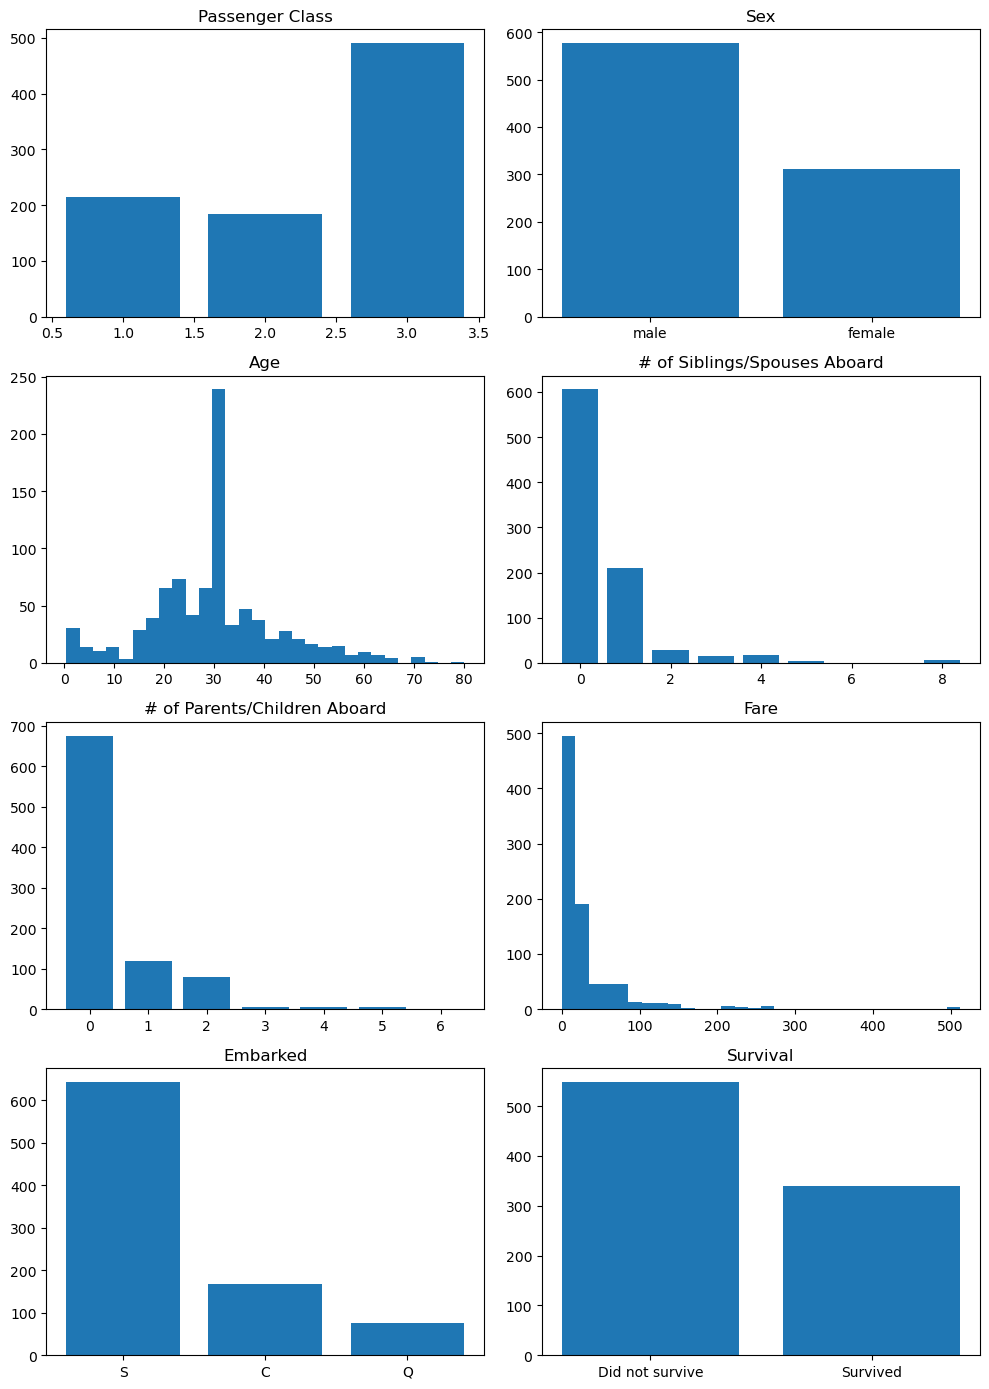

In [46]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(nrows=4, ncols=2, figsize=(10, 14))

# 1. Pclass
pclass_counts = train["Pclass"].value_counts().sort_index()
ax1.bar(pclass_counts.index, pclass_counts.values)
ax1.set_title("Passenger Class")

# 2. Sex
sex_counts = train["Sex"].value_counts()
ax2.bar(sex_counts.index, sex_counts.values)
ax2.set_title("Sex")

# 3. Age
ax3.hist(train["Age"], bins=30)
ax3.set_title("Age")

# 4. SibSp
sibsp_counts = train["SibSp"].value_counts().sort_index()
ax4.bar(sibsp_counts.index, sibsp_counts.values)
ax4.set_title("# of Siblings/Spouses Aboard")

# 5. Parch
parch_counts = train["Parch"].value_counts().sort_index()
ax5.bar(parch_counts.index, parch_counts.values)
ax5.set_title("# of Parents/Children Aboard")

# 6. Fare
ax6.hist(train["Fare"], bins=30)
ax6.set_title("Fare")

# 7. Embarked
embarked_counts = train["Embarked"].value_counts()
ax7.bar(embarked_counts.index, embarked_counts.values)
ax7.set_title("Embarked")

# 8. Survived
survived_counts = train["Survived"].value_counts().sort_index()
ax8.bar(["Did not survive", "Survived"], survived_counts.values)
ax8.set_title("Survival")

plt.tight_layout()

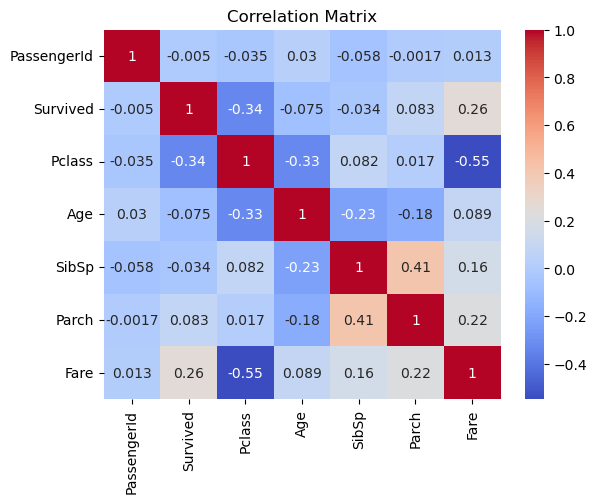

In [47]:
corr = train.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

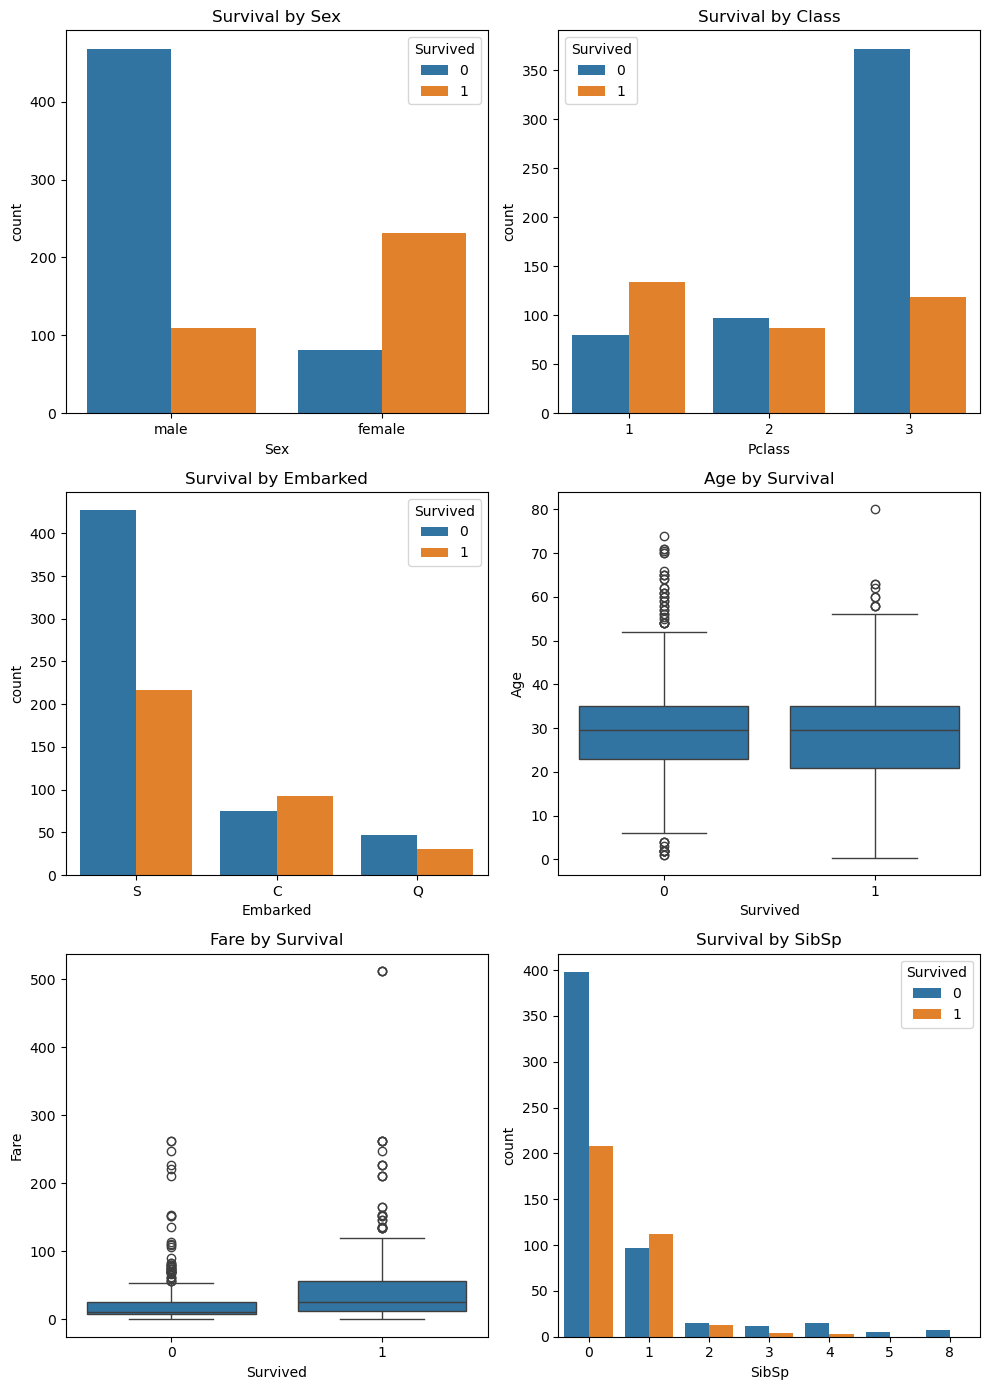

In [48]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(nrows=3, ncols=2, figsize=(10, 14))

# 1. Sex vs Survived
sns.countplot(data=train, x="Sex", hue="Survived", ax=ax1)
ax1.set_title("Survival by Sex")

# 2. Pclass vs Survived
sns.countplot(data=train, x="Pclass", hue="Survived", ax=ax2)
ax2.set_title("Survival by Class")

# 3. Embarked vs Survived
sns.countplot(data=train, x="Embarked", hue="Survived", ax=ax3)
ax3.set_title("Survival by Embarked")

# 4. Age vs Survived
sns.boxplot(data=train, x="Survived", y="Age", ax=ax4)
ax4.set_title("Age by Survival")

# 5. Fare vs Survived
sns.boxplot(data=train, x="Survived", y="Fare", ax=ax5)
ax5.set_title("Fare by Survival")

# 6. SibSp vs Survived
sns.countplot(data=train, x="SibSp", hue="Survived", ax=ax6)
ax6.set_title("Survival by SibSp")

plt.tight_layout()
plt.show()

In [49]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_train = X_train.drop(["Name", "Survived", "PassengerId"], axis=1)
y_train = y_train["Survived"]

categorical_features = ['Sex', 'Embarked']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features)],
                                  remainder="passthrough")
transformed_X = transformer.fit_transform(X_train)
transformed_X

KeyError: "['Name', 'Survived', 'PassengerId'] not found in axis"

In [37]:
from sklearn.svm import LinearSVC

clf = LinearSVC()

clf.fit(X_train, y_train)

AttributeError: 'numpy.ndarray' object has no attribute 'drop'